In [ ]:
#| default_exp models.ms_arr

In [ ]:
#| export

# from nbdev.showdoc import *
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile, expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.formatting import make_main_gt, inject_header_table_groups
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy.special import logsumexp
from scipy.stats import t, norm
import re


import warnings
warnings.filterwarnings("ignore")


class ms_arr:
    def __init__(
        self,
        n_components: int,
        target_col: str,
        lags: Optional[Union[int, List[int]]] = None,
        lag_transform: Optional[list] = None,
        difference: Optional[int] = None,
        seasonal_diff: Optional[int] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[List[int]] = None,
        box_cox: Union[bool, float, int] = False,
        box_cox_biasadj: bool = False,
        add_constant: bool = True,
        cat_variables: Optional[List[str]] = None,
        method: str = 'posterior',
        switching_var: bool = True,
        startprob_prior: float = 1e3,
        transmat_prior: float = 1e3,
        n_iter: int = 100,
        tol: float = 1e-3,
        ridge: float = 1e-5,
        coefficients: Optional[np.ndarray] = None,
        stds: Optional[np.ndarray] = None,
        init_state: Optional[np.ndarray] = None,
        trans_matrix: Optional[np.ndarray] = None,
        random_state: int = 42,
        verbose: bool = False
        ) -> None:
        
        """
        Initialize the MS-ARR model with the specified parameters.
        
        Parameters
        ----------
        n_components : int
            Number of hidden states (regimes).
        target_col : str
            Name of the target variable.
        lags : Optional[Union[int, List[int]]]
            Lags for the autoregressive model.
        lag_transform : Optional[list]
            List of lag-transform function objects applied to the target.
        difference : Optional[int]
            Order of ordinary differencing (e.g. 1 for first difference).
        seasonal_diff : Optional[int]
            Seasonal period for seasonal differencing.
        trend : Optional[str]
            Trend strategy: 'linear' or 'ets'.
        pol_degree : int
            Degree of polynomial trend (default: 1). Used when trend='linear'.
        ets_params : Dict[str, Any], optional
            Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters).
        change_points : Optional[List[int]]
            Change points for piecewise linear trend. List of indices where the trend slope can change.
        box_cox : bool or float or int, optional
            Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data.
        box_cox_biasadj : bool
            Whether to apply bias adjustment when inverting Box-Cox transformation (default: False).
        add_constant : bool
            If True, prepend a constant column to the regressor matrix (default: True).
        cat_variables : Optional[List[str]]
            Categorical feature columns (one-hot encoded).
        method : str
            State assignment method: 'posterior' (soft) or 'viterbi' (hard). Default: 'posterior'.
        switching_var : bool
            If True, each regime has its own variance. If False, uses pooled variance. Default: True.
        startprob_prior : float
            Dirichlet concentration for initial state distribution. Default: 1e3.
        transmat_prior : float
            Dirichlet concentration for transition matrix rows. Default: 1e3.
        n_iter : int
            Maximum EM iterations. Default: 100.
        tol : float
            Convergence tolerance on log-likelihood. Default: 1e-6.
        ridge : float
            Ridge regularisation parameter for coefficient estimation. Default: 1e-5.
        coefficients : Optional[np.ndarray]
            Initial regression coefficients (shape: n_states x n_features).
        stds : Optional[np.ndarray]
            Initial state standard deviations (shape: n_states,).
        init_state : Optional[np.ndarray]
            Initial state probability vector (shape: n_states,).
        trans_matrix : Optional[np.ndarray]
            Initial transition matrix (shape: n_states x n_states).
        random_state : int
            Random seed for reproducibility. Default: 42.
        verbose : bool
            If True, print EM progress. Default: False.

        Returns
        -------
        None
        """

        self.N = n_components
        self.target_col = target_col
        self.cat_variables = cat_variables
        self.cons = add_constant
        self.method = method
        self.switching_var = switching_var
        self.iter = n_iter
        self.tol = tol
        self.ridge = ridge
        self.verb = verbose
        self.coeffs = coefficients
        self.stds = stds
        self.cps = change_points
        self.pol = pol_degree
        if isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        else:
            self.box_cox = box_cox  # True or False
            self.lamda = None
        self.biasadj = box_cox_biasadj
        self.lag_transform = lag_transform

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if self.trend == "ets":
            self.ets_model = {}
            self.ets_fit = {}
            if ets_params is not None:
                # make sure ets_params is a dict with keys for both constructor and fit params
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dictionary with keys for both constructor and/or fit parameters.")
                # ExponentialSmoothing constructor params
                constructor_params = ["trend","damped_trend", "seasonal","seasonal_periods","initialization_method",
                                      "initial_level","initial_trend", "initial_seasonal","bounds","dates","freq","missing"]

                # ExponentialSmoothing.fit params
                fit_params = ["optimized","smoothing_level","smoothing_trend","smoothing_seasonal","damping_trend",
                    "remove_bias","start_params","method","minimize_kwargs","use_brute"]
                for param in constructor_params:
                    if param in ets_params:
                        self.ets_model[param] = ets_params[param]
                for param in fit_params:
                    if param in ets_params:
                        self.ets_fit[param] = ets_params[param]

        # ── lags ──────────────────────────────────────────────────────────────
        if lags is None:
            self.lags = None
        elif isinstance(lags, int):
            self.lags = list(range(1, lags + 1))
        elif isinstance(lags, list):
            if not all(isinstance(l, int) for l in lags):
                raise TypeError("lags list must contain only integers.")
            self.lags = lags
        else:
            raise TypeError("lags must be an int or a list of ints.")

        # ── differencing ──────────────────────────────────────────────────────
        self.diff = difference
        self.season_diff = seasonal_diff

        # ── HMM initialisation ────────────────────────────────────────────────
        self.rng = np.random.default_rng(random_state)

        if init_state is None:
            self.pi = self.rng.dirichlet(np.repeat(startprob_prior, self.N))
        else:
            self.pi = np.array(init_state)

        if trans_matrix is None:
            self.A = self.rng.dirichlet(np.repeat(transmat_prior, self.N), size=self.N)
        else:
            self.A = np.array(trans_matrix)

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Apply all preprocessing transformations to df and return the cleaned DataFrame.
        Also builds self.X, self.y, self.T and initialises coefficients if needed.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            for col, cats in self.cat_var.items():
                dfc[col] = pd.Categorical(dfc[col], categories=cats)
            dfc = pd.get_dummies(dfc, dtype=np.float64)
            for pat in self.drop_categ_patterns:
                cols = list(dfc.filter(regex=pat).columns)
                if cols:
                    dfc.drop(cols, axis=1, inplace=True)

        if self.target_col not in dfc.columns:
            return dfc.dropna()
        
        self.orig_target = dfc[self.target_col].values # store for generating in sample residuals later

        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = self.trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()

            if self.trend == "linear":
                if self.cps is not None:
                    self.trend_vals, self.lr_model, _ = lr_trend_model(
                        self.target_orig, degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    self.trend_vals, self.lr_model, _ = lr_trend_model(
                        self.target_orig, degree=self.pol
                    )

            elif self.trend == "ets":
                self.ets_model_fit = ExponentialSmoothing(
                    self.target_orig, **self.ets_model
                ).fit(**self.ets_fit)
                self.trend_vals = self.ets_model_fit.fittedvalues

            else:
                raise ValueError(
                    f"Unknown trend type '{self.trend}'. Use 'linear' or 'ets'."
                )
            dfc[self.target_col] = dfc[self.target_col] - self.trend_vals

        # ── Ordinary differencing ─────────────────────────────────────────────
        if self.diff is not None or self.season_diff is not None:
            self.orig = dfc[self.target_col].tolist()
            if self.diff is not None:
                dfc[self.target_col] = np.diff(
                    dfc[self.target_col], n=self.diff,
                    prepend=np.repeat(np.nan, self.diff)
                )

        # ── Seasonal differencing ─────────────────────────────────────────────
            if self.season_diff is not None:
                self.orig_d = dfc[self.target_col].tolist()
                dfc[self.target_col] = seasonal_diff(dfc[self.target_col], self.season_diff)

        # ── Lag features ──────────────────────────────────────────────────────
        if self.lags is not None:
            for lag in self.lags:
                dfc[f"{self.target_col}_lag_{lag}"] = dfc[self.target_col].shift(lag)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        # ── Build X / y arrays ────────────────────────────────────────────────
        df_clean = dfc.dropna()
        X = df_clean.drop(columns=[self.target_col])
        if self.cons:
            X = sm.add_constant(X)
        self.col_names = X.columns.tolist() if hasattr(X, 'columns') else [f"x{i}" for i in range(X.shape[1])]
        self.X = np.array(X)
        self.y = np.array(df_clean[self.target_col])
        self.T = len(self.y)

        # ── Initialise coefficients if not provided ───────────────────────────
        if self.coeffs is None or self.stds is None:
            coeffs, stds = [], []
            for _ in range(self.N):
                coeff_i = np.linalg.lstsq(self.X, self.y, rcond=None)[0]
                coeffs.append(coeff_i)
                resid = self.y - self.X @ coeff_i
                stds.append(np.sqrt(np.mean(resid ** 2)))
            self.coeffs = np.row_stack(coeffs)
            self.stds = np.array(stds)

        return df_clean

    # ─────────────────────────────────────────────────────────────────────────
    # COEFFICIENT UPDATE
    # ─────────────────────────────────────────────────────────────────────────

    def compute_coeffs(self, var_floor: float = 1e-5, w_floor: float = 1e-5):
        """Update regression coefficients and standard deviations for each state."""

        # Align X / y / posterior lengths
        if self.posterior.shape[1] < self.X.shape[0]:
            self.X = self.X[:self.posterior.shape[1]]
            self.y = self.y[:self.posterior.shape[1]]
        if self.posterior.shape[1] > self.X.shape[0]:
            self.posterior = self.posterior[:, -self.X.shape[0]:]

        X = self.X
        coeffs, stds = [], []
        weighted_resid_all, weights_all = [], []

        for s in range(self.N):
            w = self.posterior[s] + w_floor
            w /= w.sum()
            sw = np.sqrt(w)
            Xw = X * sw[:, None]
            yw = self.y * sw
            XtX = Xw.T @ Xw + self.ridge * np.eye(X.shape[1])
            Xty = Xw.T @ yw
            beta_s = np.linalg.lstsq(XtX, Xty, rcond=None)[0]
            coeffs.append(beta_s)

            resid = self.y - X @ beta_s
            weighted_resid_all.append(w * resid ** 2)
            weights_all.append(w)

            if self.switching_var:
                var_s = (w * resid ** 2).sum() / max(w.sum() - beta_s.shape[0], 1.0)
                stds.append(np.sqrt(max(var_s, var_floor)))

        if not self.switching_var:
            pooled_var = np.sum(weighted_resid_all) / (np.sum(weights_all) - X.shape[1])
            stds = [np.sqrt(max(pooled_var, var_floor))] * self.N

        self.coeffs = np.row_stack(coeffs)
        self.stds = np.array(stds)

    # ─────────────────────────────────────────────────────────────────────────
    # EMISSIONS
    # ─────────────────────────────────────────────────────────────────────────

    def _log_emissions(self):
        N, T = self.N, self.T
        logB = np.empty((N, T))
        self.fitted = np.empty((N, T))
        for s in range(N):
            mu = self.X @ self.coeffs[s]
            self.fitted[s, :] = mu
            logB[s, :] = norm.logpdf(self.y, loc=mu, scale=self.stds[s])
        return logB

    # ─────────────────────────────────────────────────────────────────────────
    # E-STEP
    # ─────────────────────────────────────────────────────────────────────────

    def _e_step_log(self):
        N, T = self.N, self.T
        logA  = np.log(self.A + 1e-300)
        logpi = np.log(self.pi + 1e-300)
        logB  = self._log_emissions()

        # Forward
        log_alpha = np.empty((N, T))
        log_alpha[:, 0] = logpi + logB[:, 0]
        for t in range(1, T):
            log_alpha[:, t] = logB[:, t] + logsumexp(log_alpha[:, t-1][:, None] + logA, axis=0)

        loglik = logsumexp(log_alpha[:, -1])

        # Backward
        log_beta = np.full((N, T), 0.0)
        for t in range(T-2, -1, -1):
            log_beta[:, t] = logsumexp(logA + (logB[:, t+1] + log_beta[:, t+1])[None, :], axis=1)

        # Gamma
        log_gamma = log_alpha + log_beta - loglik
        log_gamma -= logsumexp(log_gamma, axis=0)
        gamma = np.exp(log_gamma)

        # Xi
        log_xi = np.empty((N, N, T-1))
        for t in range(T-1):
            tmp = log_alpha[:, t][:, None] + logA + (logB[:, t+1] + log_beta[:, t+1])[None, :]
            tmp -= logsumexp(tmp)
            log_xi[:, :, t] = tmp
        xi = np.exp(log_xi)

        assert np.allclose(gamma.sum(axis=0), 1.0, atol=1e-8)
        assert np.allclose(xi.sum(axis=(0, 1)), 1.0, atol=1e-8)

        self.log_forward  = log_alpha
        self.log_backward = log_beta
        self.posterior    = gamma
        self.loglik       = loglik
        return loglik, gamma, xi

    # ─────────────────────────────────────────────────────────────────────────
    # M-STEP
    # ─────────────────────────────────────────────────────────────────────────

    def _m_step(self, gamma, xi):
        numer = xi.sum(axis=2)
        denom = gamma[:, :-1].sum(axis=1, keepdims=True)
        A = numer / (denom + 1e-12)
        A = np.maximum(A, 1e-12)
        A /= A.sum(axis=1, keepdims=True)
        self.A = A
        self.pi = gamma[:, 0] / gamma[:, 0].sum()
        self.compute_coeffs()

    def EM(self):
        loglik, gamma, xi = self._e_step_log()
        self._m_step(gamma, xi)
        self.LL = loglik

    # ─────────────────────────────────────────────────────────────────────────
    # FIT (EM training)
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
               df: pd.DataFrame
               ) -> float:
        """
        Fit the model using the EM algorithm.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.

        Returns
        -------
        float
            Final log-likelihood after EM convergence.

        """
        if self.cat_variables is not None:
            self.cat_var = {
                c: sorted(df[c].drop_duplicates().tolist(), key=lambda x: str(x))
                for c in self.cat_variables
            }
            self.drop_categ_patterns = []
            for c in self.cat_variables:
                base = sorted(df[c].drop_duplicates().tolist())[0]
                self.drop_categ_patterns.append(rf"^{re.escape(c)}_{re.escape(str(base))}$")
        self.data_prep(df)

        prev_ll = -np.inf
        self.log_likelihoods = []

        for it in range(self.iter):
            self.EM()
            if self.verb:
                print(f"Iter {it}: loglik={self.LL:.4f}")
            if it > 10 and abs(self.LL - prev_ll) < self.tol:
                if self.verb:
                    print("Converged.")
                break
            self.log_likelihoods.append(self.LL)
            prev_ll = self.LL
        self.is_fitted = True
        return self.LL

    # ─────────────────────────────────────────────────────────────────────────
    # predict_in_sample
    # ─────────────────────────────────────────────────────────────────────────

    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        fitted_values = np.sum(np.dot(self.coeffs, self.X.T) * self.posterior, axis=0)
        fit_len = len(fitted_values)
        self.in_samp_resids = self.y - fitted_values
        if not self.box_cox:
            self.fitted_values = self.orig_target[-fit_len:] + self.in_samp_resids # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
            
        else:
            bc_fitted= self.trans_data[-fit_len:] + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(
                y_pred=bc_fitted, lmda=self.lamda,
                shift=self.is_zero)
            self.in_samp_resids = self.orig_target[-fit_len:] - self.fitted_values
        # add NaNs for the initial periods where fitted values are not available due to lag features        if fit_len < len(self.orig_target):
        self.fitted_values = np.concatenate([np.repeat(np.nan, len(self.orig_target) - fit_len), self.fitted_values])
    # ─────────────────────────────────────────────────────────────────────────
    # STATE INFERENCE
    # ─────────────────────────────────────────────────────────────────────────

    def predict_states(self) -> np.ndarray:
        """Return the most likely state at each time step (hard assignment)."""
        return np.argmax(self.posterior, axis=0)

    def predict_proba(self) -> np.ndarray:
        """Return the full posterior probability matrix (N x T)."""
        return self.posterior

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _ic_base(self):
        k = (
            self.N * self.X.shape[1]       # regression coefficients
            + self.N * (self.N - 1)        # transition matrix
            + (self.N - 1)                 # initial state distribution
            + self.N                       # variance per state
        )
        n = self.T
        return k, n

    @property
    def aic(self) -> float:
        k, n = self._ic_base()
        return 2 * k - 2 * self.LL

    @property
    def aicc(self) -> float:
        k, n = self._ic_base()
        return self.aic + (2 * k * (k + 1)) / (n - k - 1)

    @property
    def bic(self) -> float:
        k, n = self._ic_base()
        return -2 * self.LL + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n = self._ic_base()
        return -2 * self.LL + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> np.ndarray:
        
        """
        Generate forecasts for H future time steps.

        Parameters
        ----------
        H : int
            Forecast horizon (number of steps to forecast ahead).
        exog : Optional[pd.DataFrame]
            Future exogenous regressors (must contain at least H rows). Should have the same columns as the training data (excluding the target variable).
        Returns
        -------
        np.ndarray
            Array of H forecasted values for the target variable.
        """

        # Rolling lag history
        y_list = self.y.tolist()

        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cons:
                if exog.shape[0] == 1:
                    exog.insert(0, 'const', 1)
                else:
                    exog = sm.add_constant(exog)
            exog = np.array(self.data_prep(exog))

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        if self.trend is not None:
            if self.trend == "linear":
                trend_forecast, _ = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            elif self.trend == "ets":
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        # ── Forward probabilities for H future steps ──────────────────────────
        logA = np.log(self.A + 1e-300)
        log_alpha = np.empty((self.N, H))
        log_alpha[:, 0] = logsumexp(self.log_forward[:, -1][:, None] + logA, axis=0)
        for t in range(1, H):
            log_alpha[:, t] = logsumexp(log_alpha[:, t-1][:, None] + logA, axis=0)
        log_alpha -= logsumexp(log_alpha, axis=0)
        self.forecast_forward = np.exp(log_alpha)
        self.state_forecasts = np.argmax(self.forecast_forward, axis=0)
        self.forecast_ps = np.zeros((self.N, H))

        # ── Recursive forecast loop ───────────────────────────────────────────
        raw_forecasts = []

        for t in range(H):
            # Exogenous features for step t
            if exog is not None:
                exo_inp = exog[t].tolist()
            else:
                exo_inp = [1] if self.cons else []

            # Lag features
            inp_lag = [y_list[-l] for l in self.lags] if self.lags is not None else []

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                series_array = np.array(y_list)
                for func in self.lag_transform:
                    transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            inp = np.array(exo_inp + inp_lag + transform_lag)

            # State-weighted prediction
            state_preds = np.array([np.dot(self.coeffs[j], inp) for j in range(self.N)])
            self.forecast_ps[:, t] = state_preds

            pred = np.sum(self.forecast_forward[:, t] * state_preds)
            raw_forecasts.append(pred)
            y_list.append(pred)

        # ── Post-processing ───────────────────────────────────────────────────
        forecasts = np.array(raw_forecasts)

        # Add back removed trend
        if self.trend is not None:
            forecasts = forecasts + trend_forecast
            self.forecast_ps += trend_forecast

        # Invert seasonal differencing
        if self.season_diff is not None:
            forecasts = invert_seasonal_diff(self.orig_d, forecasts, self.season_diff)
            for s in range(self.N):
                self.forecast_ps[s] = invert_seasonal_diff(self.orig_d, self.forecast_ps[s], self.season_diff)

        # Invert ordinary differencing
        if self.diff is not None:
            forecasts = undiff_ts(self.orig, forecasts, self.diff)
            for s in range(self.N):
                self.forecast_ps[s] = undiff_ts(self.orig, self.forecast_ps[s], self.diff)

        # Non-negativity
        forecasts = np.array([max(0, x) for x in forecasts])

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )
            for s in range(self.N):
                self.forecast_ps[s] = back_box_cox_transform(
                    y_pred=self.forecast_ps[s], lmda=self.lamda,
                    shift=self.is_zero, box_cox_biasadj=self.biasadj
                )

        return forecasts
    

    def cross_validate(self,
                       df: pd.DataFrame,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       n_iter: int = 1,
                       h_split_point: Optional[int] = None,
                       cv_df: bool = False
                       ) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
        
        """
        Run cross-validation.
        
        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the target and any feature columns.
        cv_split : int
            Number of cross-validation splits.
        test_size : int
            Number of time steps in the test set for each split.
        metrics : List[Callable]
            List of metric functions to evaluate.
        step_size : int, default=1
            Step size between the start of each test set in the splits.
        n_iter : int, default=1
            Number of EM iterations to run for each training fold.
        h_split_point : Optional[int], default=None
            If provided, split the test set into two parts at this index and evaluate metrics separately on each part.
        cv_df : bool, default=False
            If True, return a DataFrame with predictions and true values for each test fold in addition to the overall performance metrics.
        
        Returns
        -------
        pd.DataFrame
            DataFrame containing the average score for each metric across all splits. If h_split_point is provided, also includes separate scores for the two parts of the test set. If cv_df is True, returns a tuple of (overall_performance_df, cv_predictions_df)
        """

        if not self.is_fitted:
            self.fit(df)
        
        self.iter = n_iter

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])

            self.fit(train)

            # Forecast using the model
            exog_t = x_test if x_test.shape[1] > 0 else None
            bb_forecast = self.forecast(test_size, exog_t)
            # Evaluate each metric
            for m in metrics:
                if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                    eval_val = m(y_test, bb_forecast, np.array(train[self.target_col]))
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point], bb_forecast[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)

            if cv_df:
                ## store results for this split
                split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                                "split": np.repeat(f"fold_{idx+1}", len(test)), "y_true": y_test, "y_pred": bb_forecast}
                cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        return overall_performance, cv_df_
    
    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "ms_arr"

    # ─────────────────────────────────────────────────────────────────────────
    # PARAMETER SUMMARY
    # ─────────────────────────────────────────────────────────────────────────

    def get_param_spec(self):
        """
        Compute and store coefficient tables, regime statistics, and fit diagnostics.
        """
        # Weighted R² per regime and overall
        y_weighted = self.y * self.posterior
        y_wmean = y_weighted.mean(axis=1)
        self.regime_fitted = (
            self.coeffs[:, None, :] * (self.posterior[:, :, None] * self.X)
        ).sum(axis=2)

        tss_w = ((y_weighted - y_wmean[:, None]) ** 2).sum(axis=1)
        rss_w = ((y_weighted - self.regime_fitted) ** 2).sum(axis=1)
        self.regime_r2 = 1 - rss_w / tss_w

        self.fitted = self.regime_fitted.sum(axis=0)
        y_mean = np.mean(self.y)
        rss = np.sum((self.y - self.fitted) ** 2)
        tss = np.sum((self.y - y_mean) ** 2)
        self.r2 = 1 - (rss / tss)

        T = len(self.y)
        p = self.coeffs.shape[1]
        df = T - p

        arr = np.empty((p, 0))
        for s in range(self.N):
            w = np.diag(self.posterior[s])
            X_weight = np.dot(w, self.X)
            y_weight = np.dot(w, self.y)
            resid = y_weight - (self.coeffs[s] * X_weight).sum(axis=1)
            s2 = resid.T @ resid / df
            var_b = s2 * np.linalg.inv(self.X.T @ w @ self.X)
            se_b = np.sqrt(var_b)
            t_s = self.coeffs[s] / se_b.diagonal()
            p_values = (1 - t.cdf(np.abs(t_s), df)) * 2
            stats_b = np.column_stack((self.coeffs[s], se_b.diagonal(), t_s, p_values))
            arr = np.concatenate((arr, stats_b), axis=1)

        self.param_spec_df = (
            pd.DataFrame(arr, index=self.col_names)
            .reset_index()
            .rename(columns={"index": "variable"})
        )

    def summary(
        self,
        font_size: int = 12,
        row_padding: int = 4,
        col_labels_padding: int = 4
    ):
        """
        Generate a formatted summary table of the model results.

        Parameters
        ----------
        font_size : int
            Font size for the summary table (default: 12).
        row_padding : int
            Row padding in the summary table (default: 4).
        col_labels_padding : int
            Column label padding in the summary table (default: 4).
        """
        self.get_param_spec()

        # Regime probabilities
        state_probs = pd.DataFrame(
            pd.Series(self.predict_states()).value_counts(normalize=True).sort_index()
        )
        state_probs.index = [f"regime_{i+1}" for i in state_probs.index]
        state_probs[state_probs.select_dtypes(include='number').columns] = (
            state_probs.select_dtypes(include='number').applymap(lambda x: f"{x:.3f}")
        )
        state_probs = state_probs.T

        # Regime variances
        reg_vars = pd.DataFrame([{
            f"regime_{i+1}": f"{v:.3f}"
            for i, v in enumerate(np.round(self.stds ** 2, 3))
        }])

        # Transition matrix
        tm = pd.DataFrame(
            self.A,
            columns=[f"regime_{i+1}" for i in range(self.A.shape[1])],
            index=[f"regime_{i+1}" for i in range(self.A.shape[0])]
        )
        tm_df = tm.reset_index().rename(columns={"index": ""})
        tm_df[tm_df.select_dtypes(include='number').columns] = (
            tm_df.select_dtypes(include='number').applymap(lambda x: f"{x:.3f}")
        )

        # Data info
        data = {
            "dep. Variable": self.target_col,
            "n_obs": len(self.y),
            "df_model": self.coeffs.shape[1],
        }
        data_df = pd.DataFrame([data]).T.rename(columns={0: " "})
        data_df = data_df.reset_index().rename(columns={"index": ""})

        # Diagnostics
        diagn = {"overall_R-squared": round(self.r2, 3)}
        diagn.update({f"regime_{i+1}_R-squared": round(j, 3) for i, j in enumerate(self.regime_r2)})
        diagn.update({
            "log-likelihood": round(self.loglik, 1),
            "AIC": round(self.aic, 1),
            "BIC": round(self.bic, 1),
        })
        diagnosis_df = pd.DataFrame([diagn]).T.rename(columns={0: "diagnostics"})
        diagnosis_df = diagnosis_df.reset_index().rename(columns={"index": ""})

        gt_main = make_main_gt(self.param_spec_df, n_regimes=self.N)
        gt_final = inject_header_table_groups(
            gt_main,
            columns=[
                [("Regime probabilities", state_probs, True),
                 ("Regime variances", reg_vars, True)],
                [("Transition probabilities", tm_df, True)],
                [("Data", data_df, False)],
                [("Diagnostics", diagnosis_df, False)],
            ],
            subtitle_text="Regime-switching hidden markov regression model results"
        ).tab_options(
            table_font_size=f"{font_size}px",
            data_row_padding=f"{row_padding}px",
            column_labels_padding=f"{col_labels_padding}px",
        )
        return gt_final


In [ ]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [ ]:
#| echo: false
docments(ms_arr, full=True)
DocmentTbl(ms_arr)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| n_components | int |  | Number of hidden states (regimes). |
| target_col | str |  | Name of the target variable. |
| lags | Optional[Union[int, List[int]]] | None | Lags for the autoregressive model. |
| lag_transform | Optional[list] | None | List of lag-transform function objects applied to the target. |
| difference | Optional[int] | None | Order of ordinary differencing (e.g. 1 for first difference). |
| seasonal_diff | Optional[int] | None | Seasonal period for seasonal differencing. |
| trend | Optional[str] | None | Trend strategy: 'linear' or 'ets'. |
| pol_degree | int | 1 | Degree of polynomial trend (default: 1). Used when trend='linear'. |
| ets_params | Optional[Dict[str, Any]] | None | Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters). |
| change_points | Optional[List[int]] | None | Change points for piecewise linear trend. List of indices where the trend slope can change. |
| box_cox | Union[bool, float, int] | False | Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data. |
| box_cox_biasadj | bool | False | Whether to apply bias adjustment when inverting Box-Cox transformation (default: False). |
| add_constant | bool | True | If True, prepend a constant column to the regressor matrix (default: True). |
| cat_variables | Optional[List[str]] | None | Categorical feature columns (one-hot encoded). |
| method | str | posterior | State assignment method: 'posterior' (soft) or 'viterbi' (hard). Default: 'posterior'. |
| switching_var | bool | True | If True, each regime has its own variance. If False, uses pooled variance. Default: True. |
| startprob_prior | float | 1000.0 | Dirichlet concentration for initial state distribution. Default: 1e3. |
| transmat_prior | float | 1000.0 | Dirichlet concentration for transition matrix rows. Default: 1e3. |
| n_iter | int | 100 | Maximum EM iterations. Default: 100. |
| tol | float | 0.001 | Convergence tolerance on log-likelihood. Default: 1e-6. |
| ridge | float | 1e-05 | Ridge regularisation parameter for coefficient estimation. Default: 1e-5. |
| coefficients | Optional[np.ndarray] | None | Initial regression coefficients (shape: n_states x n_features). |
| stds | Optional[np.ndarray] | None | Initial state standard deviations (shape: n_states,). |
| init_state | Optional[np.ndarray] | None | Initial state probability vector (shape: n_states,). |
| trans_matrix | Optional[np.ndarray] | None | Initial transition matrix (shape: n_states x n_states). |
| random_state | int | 42 | Random seed for reproducibility. Default: 42. |
| verbose | bool | False | If True, print EM progress. Default: False. |
| **Returns** | **None** |  |  |

In [ ]:
#| echo: false
show_doc(ms_arr.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_arr.py#L446){target="_blank" style="float:right; font-size:smaller"}

### ms_arr.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing the target and any feature columns.
)->float: # Final log-likelihood after EM convergence.


```

*Fit the model using the EM algorithm.*

In [ ]:
#| echo: false
DocmentTbl(ms_arr.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing the target and any feature columns. |
| **Returns** | **float** | **Final log-likelihood after EM convergence.** |

In [ ]:
#| echo: false
show_doc(ms_arr.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_arr.py#L571){target="_blank" style="float:right; font-size:smaller"}

### ms_arr.forecast

```python

def forecast(
    H:int, # Forecast horizon (number of steps to forecast ahead).
    exog:Optional[pd.DataFrame]=None, # Future exogenous regressors (must contain at least H rows). Should have the same columns as the training data (excluding the target variable).
)->np.ndarray:


```

*Generate forecasts for H future time steps.*

In [ ]:
#| echo: false
DocmentTbl(ms_arr.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon (number of steps to forecast ahead). |
| exog | Optional[pd.DataFrame] | None | Future exogenous regressors (must contain at least H rows). Should have the same columns as the training data (excluding the target variable). |
| **Returns** | **np.ndarray** |  |  |

In [ ]:
#| echo: false
show_doc(ms_arr.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ms_arr.py#L693){target="_blank" style="float:right; font-size:smaller"}

### ms_arr.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # DataFrame containing the target and any feature columns.
    cv_split:int, # Number of cross-validation splits.
    test_size:int, # Number of time steps in the test set for each split.
    metrics:List[Callable], # List of metric functions to evaluate.
    step_size:int=1, # Step size between the start of each test set in the splits.
    n_iter:int=1, # Number of EM iterations to run for each training fold.
    h_split_point:Optional[int]=None, # If provided, split the test set into two parts at this index and evaluate metrics separately on each part.
    cv_df:bool=False, # If True, return a DataFrame with predictions and true values for each test fold in addition to the overall performance metrics.
)->Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]: # DataFrame containing the average score for each metric across all splits. If h_split_point is provided, also includes separate scores for the two parts of the test set. If cv_df is True, returns a tuple of (overall_performance_df, cv_predictions_df)


```

*Run cross-validation.*

In [ ]:
#| echo: false
DocmentTbl(ms_arr.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | DataFrame containing the target and any feature columns. |
| cv_split | int |  | Number of cross-validation splits. |
| test_size | int |  | Number of time steps in the test set for each split. |
| metrics | List[Callable] |  | List of metric functions to evaluate. |
| step_size | int | 1 | Step size between the start of each test set in the splits. |
| n_iter | int | 1 | Number of EM iterations to run for each training fold. |
| h_split_point | Optional[int] | None | If provided, split the test set into two parts at this index and evaluate metrics separately on each part. |
| cv_df | bool | False | If True, return a DataFrame with predictions and true values for each test fold in addition to the overall performance metrics. |
| **Returns** | **Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]** |  | **DataFrame containing the average score for each metric across all splits. If h_split_point is provided, also includes separate scores for the two parts of the test set. If cv_df is True, returns a tuple of (overall_performance_df, cv_predictions_df)** |

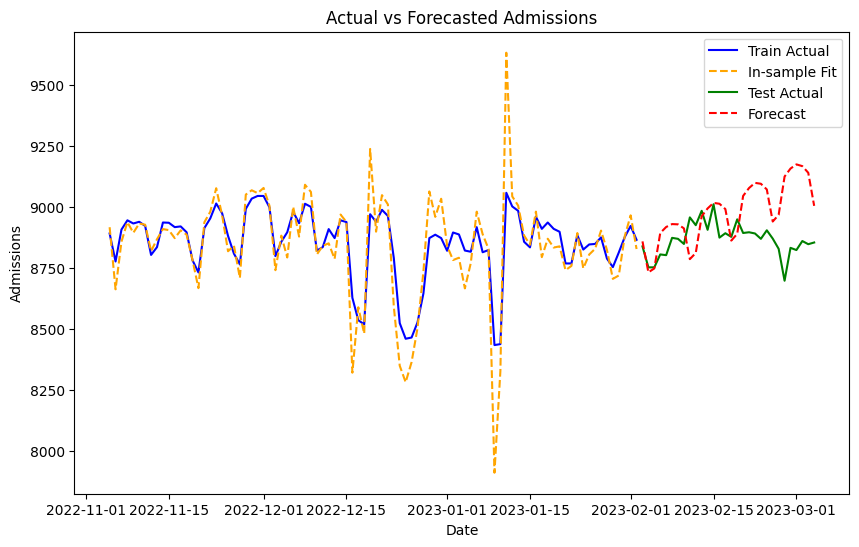

In [ ]:
#| hide
from peshbeen.datasets import load_wales_admissions
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]
cat_variables = ["day_of_week", "month"]

ms_model = ms_arr(n_components=2, target_col='admissions', lags=14, trend="linear",
                  cat_variables=cat_variables, switching_var=True, n_iter=40)

ms_model.fit(train)
forecasts = ms_model.forecast(H=30, exog=test[cat_variables])

ms_model.predict_in_sample()
fit_vals = ms_model.fitted_values

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], fit_vals[-90:], label='In-sample Fit', color='orange', linestyle='--')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Actual vs Forecasted Admissions')
plt.legend()
plt.show()

In [ ]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cv_results = ms_model.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=30, cv_df=False, n_iter=10)
cv_results

(  eval_metric       score
 0       WMAPE    0.026981
 1         MAE  239.252178
 2        RMSE  272.719529,
 Empty DataFrame
 Columns: []
 Index: [])